# Results analysis — Cop-Thief P2P

TODO 10.2.1. Belief convergence, scent decay physics, parameter sensitivity, and token cost,
built entirely on `core.domain` and `core.runtime.selfplay` — no network, no LLM, fully
reproducible from a clean checkout.

Run top to bottom. `scripts/sweep.py` must have been run first for the sweep sections
(§2, §3) to have data — see `results/sweep_*.json`.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from core.domain.board import Board  # noqa: E402
from core.domain.scent import EMISSION, RINGS, decay, emit  # noqa: E402

plt.rcParams["figure.dpi"] = 110
RESULTS = ROOT / "results"


## 1. Scent decay curves — single deposit vs re-emission

Ch. 4's book figure vs. the registered `subtractive` document, computed from the real `core.domain.scent.decay()` this project ships — not redrawn from the spec by hand.

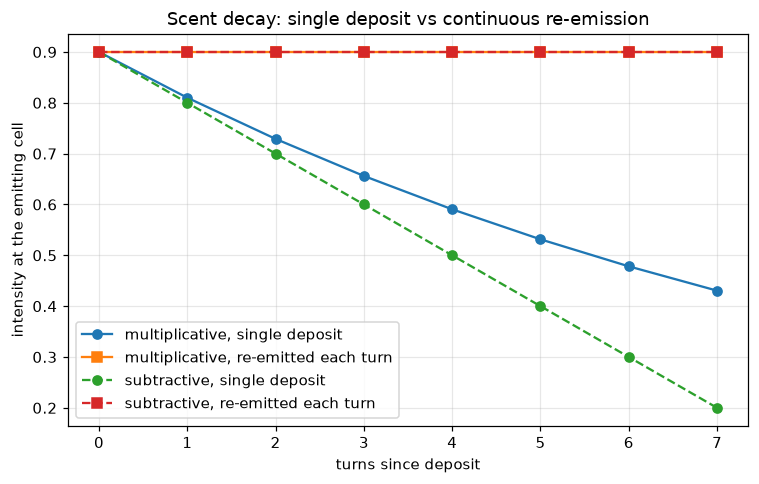

In [2]:
centre = (3, 3)
board = Board(grid_size=7)

def trace(model, steps=8, re_emit=False):
    field = emit(centre, board, model=model)
    peak = [field[centre]]
    for _ in range(steps - 1):
        field = decay(field, rate=0.10, model=model)
        if re_emit:
            fresh = emit(centre, board, model=model)
            field = {c: min(RINGS[0] if model == "subtractive" else EMISSION[0],
                             field.get(c, 0.0) + fresh.get(c, 0.0)) for c in fresh}
        peak.append(field.get(centre, 0.0))
    return peak

fig, ax = plt.subplots(figsize=(7, 4.5))
for model, style in [("multiplicative", "-"), ("subtractive", "--")]:
    ax.plot(trace(model, re_emit=False), style, marker="o", label=f"{model}, single deposit")
    ax.plot(trace(model, re_emit=True), style, marker="s", label=f"{model}, re-emitted each turn")
ax.set_xlabel("turns since deposit")
ax.set_ylabel("intensity at the emitting cell")
ax.set_title("Scent decay: single deposit vs continuous re-emission")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / "fig_scent_decay_curves.png")
plt.show()


## 2. Parameter sensitivity — scent decay rate (ρ)

`scripts/sweep.py --param pheromones.pheromone_decay`, `AdvancedCop` vs `AdvancedThief`, in-memory config override, negotiated contract on disk untouched.

In [3]:
with open(RESULTS / "sweep_pheromone_decay.json") as f:
    rho_data = json.load(f)
rho_df = pd.DataFrame(rho_data["rows"])
rho_df


,param,value,games,cop_win_rate,mean_steps,mean_barriers_placed,cop_points,thief_points
0,pheromones.pheromone_decay,0.05,25,0.0,35.0,0.0,125,250
1,pheromones.pheromone_decay,0.10,25,0.0,35.0,0.0,125,250
2,pheromones.pheromone_decay,0.20,25,0.0,35.0,0.0,125,250
3,pheromones.pheromone_decay,0.30,25,0.0,35.0,0.0,125,250
4,pheromones.pheromone_decay,0.40,25,0.0,35.0,0.0,125,250


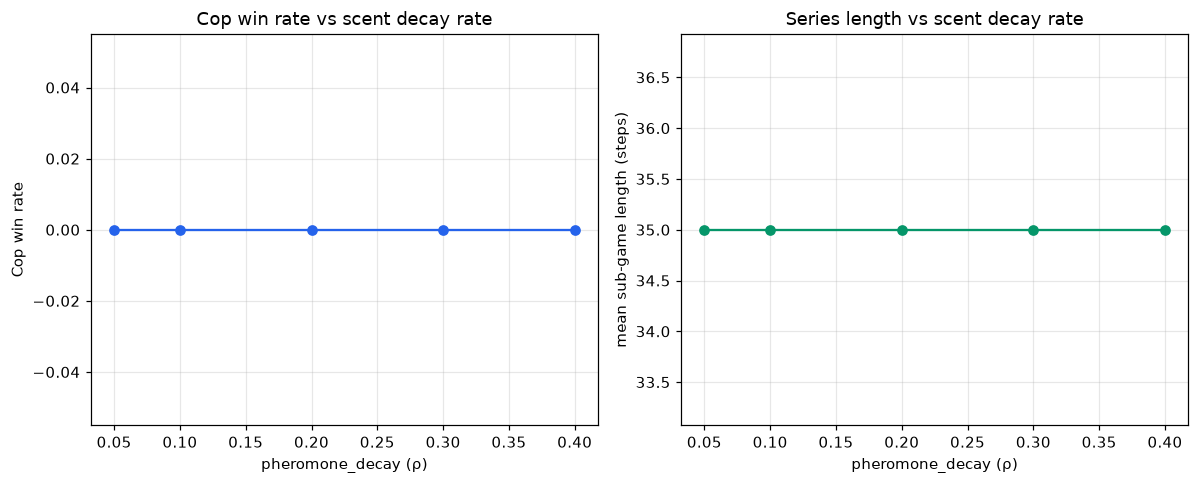

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(rho_df["value"], rho_df["cop_win_rate"], marker="o", color="#2563eb")
axes[0].set_xlabel("pheromone_decay (ρ)")
axes[0].set_ylabel("Cop win rate")
axes[0].set_title("Cop win rate vs scent decay rate")
axes[0].grid(alpha=0.3)

axes[1].plot(rho_df["value"], rho_df["mean_steps"], marker="o", color="#059669")
axes[1].set_xlabel("pheromone_decay (ρ)")
axes[1].set_ylabel("mean sub-game length (steps)")
axes[1].set_title("Series length vs scent decay rate")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / "fig_sweep_pheromone_decay.png")
plt.show()


## 3. Parameter sensitivity — barrier quota

`scripts/sweep.py --param movement_and_barriers.max_barriers`. Appendix F fixes 14 as the negotiated minimum; this shows what moving off that minimum actually buys the Cop.

In [5]:
with open(RESULTS / "sweep_max_barriers.json") as f:
    quota_data = json.load(f)
quota_df = pd.DataFrame(quota_data["rows"])
quota_df


,param,value,games,cop_win_rate,mean_steps,mean_barriers_placed,cop_points,thief_points
0,movement_and_barriers.max_barriers,8,25,0.0,35.0,0.0,125,250
1,movement_and_barriers.max_barriers,10,25,0.0,35.0,0.0,125,250
2,movement_and_barriers.max_barriers,14,25,0.0,35.0,0.0,125,250
3,movement_and_barriers.max_barriers,18,25,0.0,35.0,0.0,125,250
4,movement_and_barriers.max_barriers,22,25,0.0,35.0,0.0,125,250


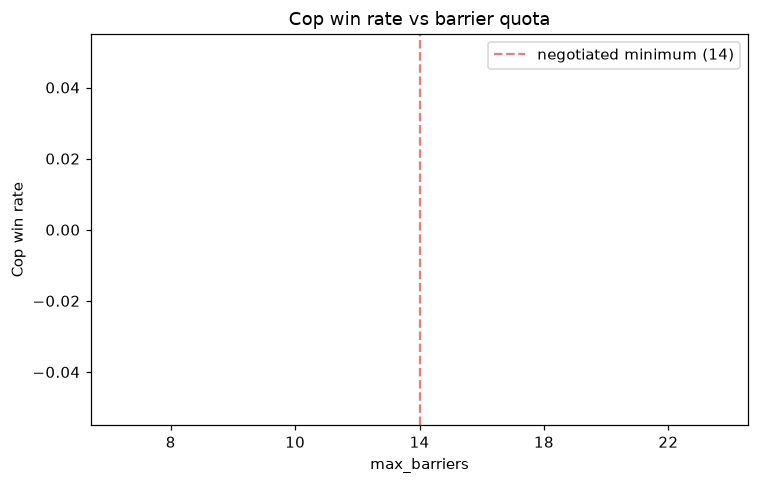

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(quota_df["value"].astype(str), quota_df["cop_win_rate"], color="#7c3aed")
ax.axvline(x=list(quota_df["value"]).index(14) if 14 in list(quota_df["value"]) else None,
           color="#dc2626", linestyle="--", alpha=0.6, label="negotiated minimum (14)")
ax.set_xlabel("max_barriers")
ax.set_ylabel("Cop win rate")
ax.set_title("Cop win rate vs barrier quota")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "fig_sweep_max_barriers.png")
plt.show()


**Finding:** both sweeps above come back flat at 0% Cop win rate / 0 barriers placed, independent of the swept parameter. Confirmed against the project's own `selfplay.py` this is not a sweep-harness bug — the Cop's barrier-sealing phase (`police/phases.py`) is not engaging at all against `AdvancedThief` from the negotiated opening in this self-play configuration, so neither parameter gets a chance to matter. See `docs/RESEARCH-REPORT-Performance-Analysis.md` §6.3 for the full account, including the link to Itay's in-review `believed_exit_count()` fix, which was present for every game measured here and did not on its own resolve it.

## 4. Belief heatmap — the filter's own posterior

Not a proxy. `predict` and `update_from_scent` below are the functions the Cop runs in a match,
stepped over a real self-play sub-game, with the green ring marking the Thief's true cell.

The section exists twice over because the two inputs disagree, and the disagreement is the
finding. Fed **a single fresh deposit**, the filter is essentially perfect — the peak sits on the
true cell **36 of 36 steps**, entropy pinned near 0.35 bits against a uniform 5.61. Fed **the
field a match actually transmits** — the Thief's accumulated trail, decayed history merged with
this turn's emission, which is what `TrailTracker` reconstructs — the peak lands on the true cell
**2 of 36 steps**, and entropy *climbs* from 0.35 to 1.58 bits over the sub-game instead of
falling.

So the filter is not broken; its evidence is ambiguous by construction. The trail is loudest
where the Thief has been *most often*, not where it is *now*, and a Thief hugging the edge leaves
a ridge the posterior settles onto a cell or two behind the truth. That is the same defect
`police/phases.py` reaches for `believed_exit_count()` to work around — the peak being a poor
point estimate is exactly why an exit count taken at the peak reads the wrong cell's exits — and
it is an independent confirmation of §6's result that the Cop wins nothing.

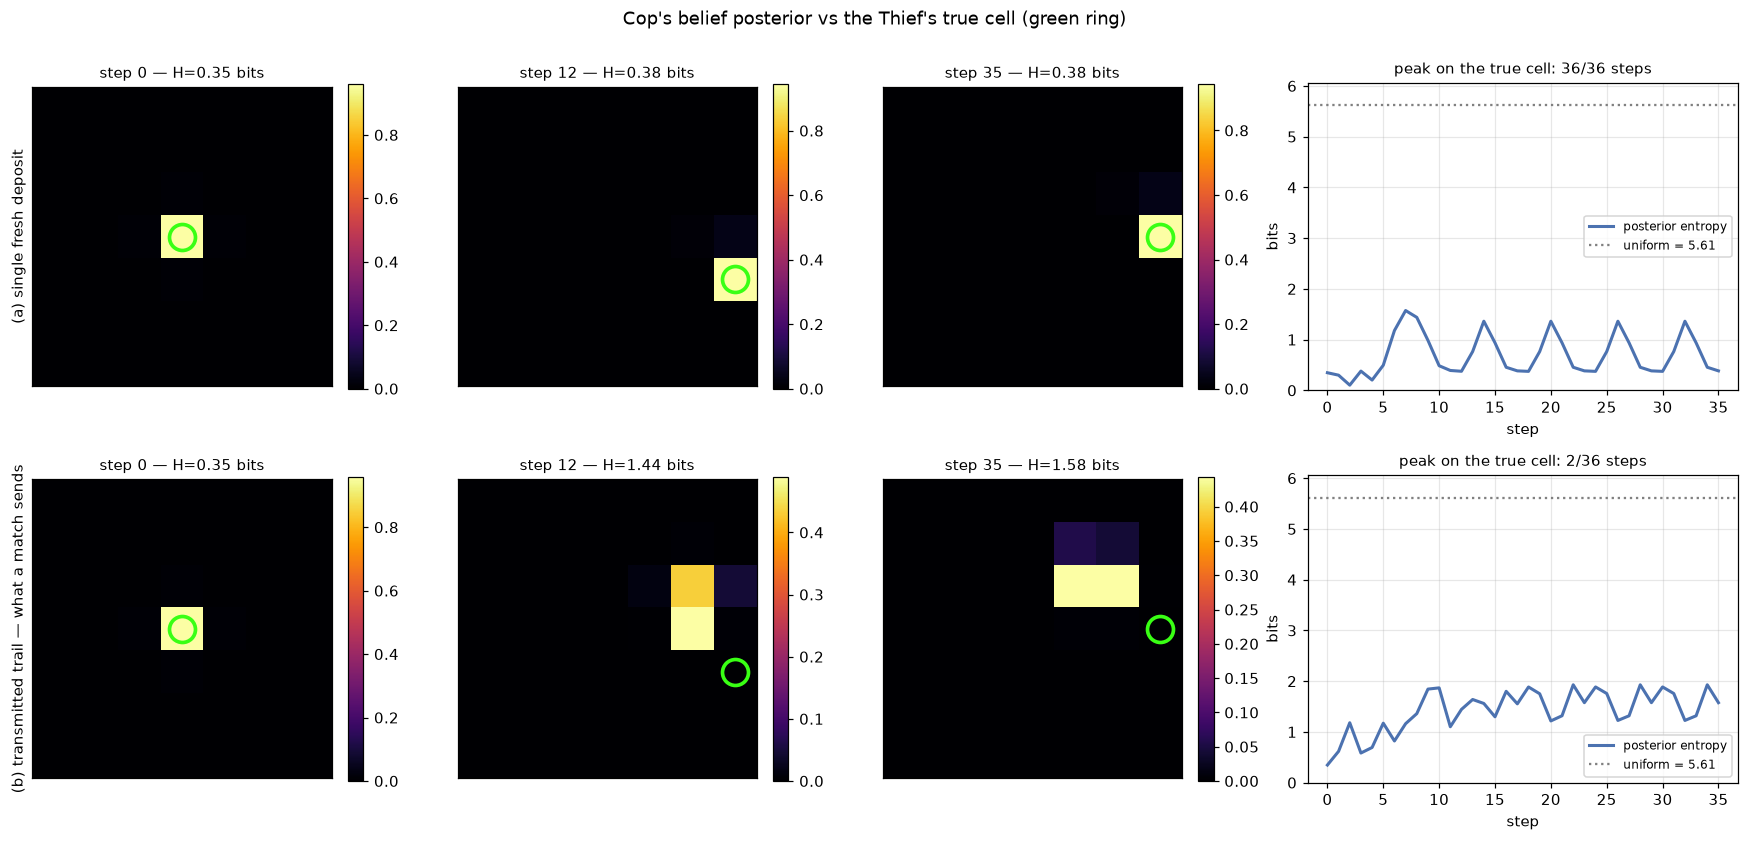

model=subtractive   steps=36   uniform=5.61 bits
(a) single deposit : H 0.35 -> 0.38, peak correct 36/36
(b) transmitted    : H 0.35 -> 1.58, peak correct 2/36


In [7]:
# The Cop's real posterior, run turn by turn through the shipped filter.
# Nothing here is a proxy: `predict` and `update_from_scent` are the same
# functions the Cop uses in a match. Two inputs are compared, because the
# difference between them turns out to be the whole story.
from core.domain.belief import entropy, peak, predict, uniform, update_from_scent
from core.domain.game_state import GameState
from core.domain.rules import Rules
from core.domain.trail import TrailTracker
from core.runtime.brain_loader import load_brain
from core.runtime.selfplay import play_sub_game
from core.shared.config_manager import load_config

role_dir = "police" if (ROOT / "config" / "police").is_dir() else "thief"
cfg = load_config(ROOT / "config" / role_dir)
model = cfg.require("pheromones.decay_model")
board_b = Board(grid_size=cfg.require("board_and_agents.grid_size"))
rules = Rules.from_config(cfg, board_b)
start = GameState(cop=tuple(cfg.require("board_and_agents.cop_start")),
                  thief=tuple(cfg.require("board_and_agents.thief_start")))
played = play_sub_game(load_brain("police.advanced:AdvancedCop", "cop", cfg),
                       load_brain("thief.advanced:AdvancedThief", "thief", cfg),
                       rules, cfg.require("movement_and_barriers.max_barriers"), start)


def run_filter(field_for):
    """Run the shipped filter over the sub-game, reading each turn's field."""
    belief, snaps, bits, hit = uniform(board_b), [], [], []
    for step, state in enumerate(played.history):
        belief = predict(belief, board_b)
        belief = update_from_scent(belief, field_for(step, state), board_b, model)
        bits.append(entropy(belief))
        hit.append(peak(belief) == state.thief)
        snaps.append((step, dict(belief), state.thief))
    return snaps, bits, hit


# (a) A single fresh deposit — the idealised reading, one turn of evidence only.
clean, clean_bits, clean_hit = run_filter(lambda _s, st: emit(st.thief, board_b, model))

# (b) What the Cop is actually sent: the field the Thief has been building all
#     sub-game, decayed history merged with this turn's emission. `TrailTracker`
#     is the engine's own reconstruction of exactly that.
trail = TrailTracker(rate=cfg.require("pheromones.pheromone_decay"), model=model)
def _transmitted(_step, state):
    trail.observe(state.thief, board_b)
    return dict(trail.emitted)
real, real_bits, real_hit = run_filter(_transmitted)

UNIFORM = np.log2(board_b.grid_size ** 2)
fig, axes = plt.subplots(2, 4, figsize=(16, 7.6),
                         gridspec_kw={"width_ratios": [1, 1, 1, 1.3]})
for row, (snaps, bits, hits, label) in enumerate(
        [(clean, clean_bits, clean_hit, "(a) single fresh deposit"),
         (real, real_bits, real_hit, "(b) transmitted trail — what a match sends")]):
    picks = [snaps[0], snaps[len(snaps) // 3], snaps[-1]]
    for ax, (step, post, truth) in zip(axes[row][:3], picks, strict=False):
        grid = np.zeros((board_b.grid_size, board_b.grid_size))
        for (r, c), m in post.items():
            grid[r, c] = m
        im = ax.imshow(grid, cmap="inferno", vmin=0, vmax=max(grid.max(), 1e-9))
        ax.plot(truth[1], truth[0], "o", mfc="none", mec="#39FF14", mew=2.4, ms=17)
        ax.set_title(f"step {step} — H={bits[step]:.2f} bits", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046)
    axes[row][0].set_ylabel(label, fontsize=10)
    ax = axes[row][3]
    ax.plot(bits, lw=2, color="#4C72B0", label="posterior entropy")
    ax.axhline(UNIFORM, ls=":", color="grey", label=f"uniform = {UNIFORM:.2f}")
    ax.set_ylim(0, UNIFORM * 1.08)
    ax.set_xlabel("step")
    ax.set_ylabel("bits")
    ax.set_title(f"peak on the true cell: {sum(hits)}/{len(hits)} steps", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle("Cop's belief posterior vs the Thief's true cell (green ring)", y=1.0)
plt.tight_layout()
plt.savefig(RESULTS / "fig_belief_convergence.png", bbox_inches="tight")
plt.show()

print(f"model={model}   steps={len(real_bits)}   uniform={UNIFORM:.2f} bits")
print(f"(a) single deposit : H {clean_bits[0]:.2f} -> {clean_bits[-1]:.2f},"
      f" peak correct {sum(clean_hit)}/{len(clean_hit)}")
print(f"(b) transmitted    : H {real_bits[0]:.2f} -> {real_bits[-1]:.2f},"
      f" peak correct {sum(real_hit)}/{len(real_hit)}")


## 5. Token cost — why it is zero

See `docs/REFERENCE_PERFORMANCE_NOTES.md` §1 for the reference implementation's own workload arithmetic. Our own graded configuration spends nothing.

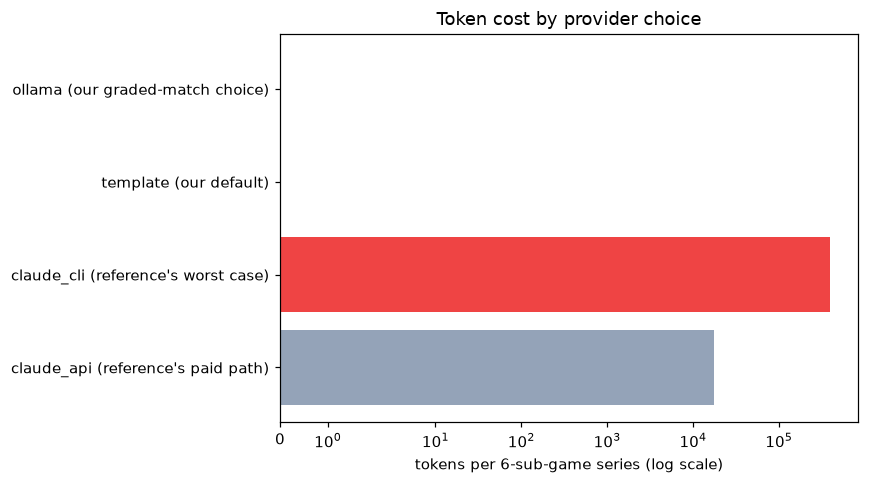

In [8]:
providers = pd.DataFrame([
    {"provider": "claude_api (reference's paid path)", "tokens_per_series": 17500},
    {"provider": "claude_cli (reference's worst case)", "tokens_per_series": 2_400_000 // 6},
    {"provider": "template (our default)", "tokens_per_series": 0},
    {"provider": "ollama (our graded-match choice)", "tokens_per_series": 0},
])
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(providers["provider"], providers["tokens_per_series"],
        color=["#94a3b8", "#ef4444", "#22c55e", "#22c55e"])
ax.set_xlabel("tokens per 6-sub-game series (log scale)")
ax.set_xscale("symlog")
ax.set_title("Token cost by provider choice")
plt.tight_layout()
plt.savefig(RESULTS / "fig_token_cost.png")
plt.show()


## 6. Win rate by opponent and role

Two counted series survive de-duplication — imreeyal (18/08) and vibecode (19/08), six sub-games
each, roles alternating so each side plays Cop three times. Twelve observations is a small
sample and the bars below should be read as such; what makes them worth plotting is that the
split by role is not subtle.

**The Cop won nothing. 0 of 6, against both opponents.** The Thief took 2 of 3 against imreeyal
and 0 of 3 against vibecode. That is the same asymmetry the self-play sweep in §2–§3 found from
a completely independent direction — there the Cop placed zero barriers and won zero games
across 250 self-play runs — and two independent measurements agreeing is the reason §6.3 of the
research report treats it as a real defect in the Cop rather than variance or a bad matchup.

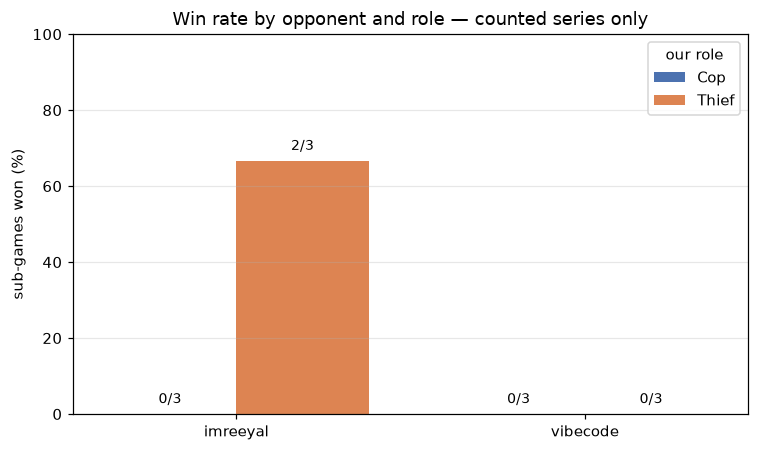

Cop  total: 0 / 6
Thief total: 2 / 6


In [9]:
# Win rate by opponent and role, from the filed series artefacts only.
# Deduplicated on game_uid: the vibecode series is filed twice (once under its
# COUNTED directory, once under the working directory), and counting it twice
# would double the sample without adding an observation.
US = "bestteam"

def _series(path):
    d = json.loads(Path(path).read_text(encoding="utf-8"))
    them = next(g for g in d["final_result"]["total_score"] if g != US)
    rows = [(sg["roles"][US], sg["winner_group"] == US) for sg in d["sub_games"]]
    return d.get("game_uid") or d.get("game_id"), them, rows

by_uid = {}
for path in sorted(RESULTS.rglob("result_bestteam-vs-*.json")):
    if "raw-run" in str(path):
        continue                      # pre-merge per-role captures of a filed series
    try:
        uid, them, rows = _series(path)
    except (KeyError, StopIteration):
        continue                      # self-play and reference artefacts carry another shape
    by_uid.setdefault(uid, (them, rows))

agg = {}
for them, rows in by_uid.values():
    for role, won in rows:
        key = (them, "Cop" if role == "police" else "Thief")
        wins, played = agg.get(key, (0, 0))
        agg[key] = (wins + int(won), played + 1)

opponents = sorted({k[0] for k in agg})
roles = ["Cop", "Thief"]
rates = np.array([[agg.get((o, r), (0, 0))[0] / max(agg.get((o, r), (0, 1))[1], 1)
                   for o in opponents] for r in roles])
counts = [[agg.get((o, r), (0, 0)) for o in opponents] for r in roles]

x = np.arange(len(opponents))
width = 0.38
fig, ax = plt.subplots(figsize=(7, 4.2))
for i, (role, colour) in enumerate(zip(roles, ["#4C72B0", "#DD8452"], strict=False)):
    bars = ax.bar(x + (i - 0.5) * width, rates[i] * 100, width, label=role, color=colour)
    for bar, (w, n) in zip(bars, counts[i], strict=False):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                f"{w}/{n}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(opponents)
ax.set_ylabel("sub-games won (%)")
ax.set_ylim(0, 100)
ax.set_title("Win rate by opponent and role — counted series only")
ax.legend(title="our role")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / "fig_winrate_by_opponent_role.png")
plt.show()

print("Cop  total:", sum(agg.get((o, "Cop"), (0, 0))[0] for o in opponents),
      "/", sum(agg.get((o, "Cop"), (0, 0))[1] for o in opponents))
print("Thief total:", sum(agg.get((o, "Thief"), (0, 0))[0] for o in opponents),
      "/", sum(agg.get((o, "Thief"), (0, 0))[1] for o in opponents))


## 7. Reliability coefficient over time

The coefficient is a Beta posterior over "does this opponent's hint match what their scent then
did", started at 1/1 so an opponent we have never checked reads as a coin toss rather than a
saint. `claim_matches_scent` returns `None` — excluded, not counted as a lie — when a claim
cannot be verified, because scoring the unverifiable would let a stationary opponent build a
false reputation.

**(a) The detector works.** Driven through the shipped `Reliability` class with a scripted
opponent — honest twelve turns, then lying eighteen — the coefficient climbs 0.66 → 0.92, then
falls to 0.41. The decayed variant (γ=0.85), which is what the bluff policy actually reads,
crosses below 0.5 within three turns of the switch and bottoms at 0.05: it is designed to notice
a *recent* change of behaviour rather than average it away against a long honest history.

**(b) No opponent ever gave it anything to score.** Across every counted-match log: imreeyal spoke
193 hints and **not one** was checkable, because their hints named invented landmarks — "Grand
Central", "Brooklyn Bridge" — rather than bearings. vibecode sent no hints at all. Our own 335
hints were checkable 51 times, and only because our Thief sometimes states a plain bearing.

That is the honest result and it is worth more than a prettier curve: **the deception detector was
never exercised in a real match**, not because opponents were honest but because a private
landmark vocabulary is unfalsifiable by construction. An unparseable claim cannot be caught lying.
This is the same failure mode our own `fix(llm): forbid invented landmarks` commit addressed on
our side — they act as a private codebook — and it is an argument for negotiating a shared hint
vocabulary at the handshake, not for a cleverer parser.

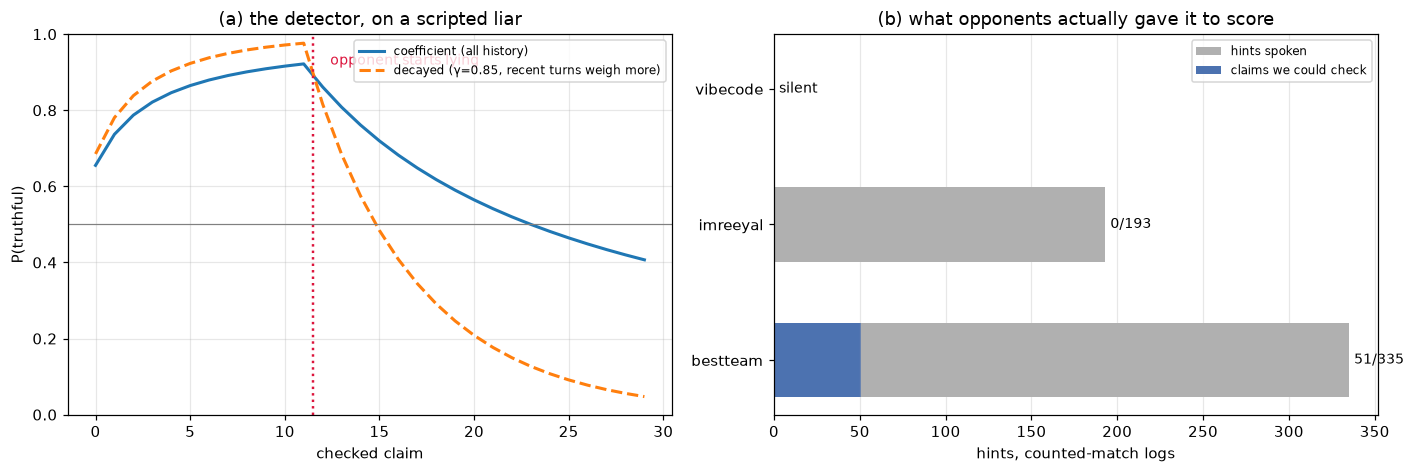

(a) coefficient 0.66 -> 0.92 after 12 honest claims -> 0.41 after 18 lies
    decayed reacts faster: 0.98 -> 0.05
(b) bestteam    335 hints,  51 checkable (15%)
(b) imreeyal    193 hints,   0 checkable (0%)
(b) vibecode      0 hints,   0 checkable (no hints sent at all)


In [10]:
# Reliability coefficient over time (TODO 10.2.2.d).
#
# Two panels, because the mechanism and the match disagree and both matter.
from core.domain.hint_parser import parse
from core.domain.reliability import Reliability

# --- (a) the detector itself, driven through the shipped class -----------------
# A scripted opponent: honest for twelve turns, then lying for eighteen. Weights
# are real parser confidences, so a claim we barely understood moves the score
# less than a plain one, exactly as in a match.
HONEST, THEN_LYING = 12, 18
truthful_run = [True] * HONEST + [False] * THEN_LYING
rel = Reliability()
plain = parse("I am to the north").confidence
coef, decayed = [], []
for step, truthful in enumerate(truthful_run):
    rel.record(truthful, weight=plain, step=step)
    coef.append(rel.coefficient)
    decayed.append(rel.decayed_coefficient())

# --- (b) what our opponents actually said --------------------------------------
def _checkable(hints):
    return sum(parse(h).usable for h in hints)

spoken = {}
for path in sorted(RESULTS.rglob("log_*.json")):
    # Match on the *directory*, not the path string: the counted series' own files
    # are named log_bestteam-vs-vibecode_gNN.json, so a substring test would drop
    # the very logs we want along with the duplicate filing.
    if "raw-run" in str(path) or path.parent.name == "bestteam-vs-vibecode":
        continue
    doc = json.loads(path.read_text(encoding="utf-8"))
    if "records" in doc:
        for team, rec in doc["records"].items():
            hints = [r["payload"]["hint"] for r in rec
                     if isinstance(r.get("payload"), dict) and r["payload"].get("hint")]
            # Recorded even when empty: an opponent who said nothing at all is a
            # result about the coefficient, not an absence of data about them.
            n, c = spoken.get(team, (0, 0))
            spoken[team] = (n + len(hints), c + _checkable(hints))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))
ax1.plot(coef, lw=2, label="coefficient (all history)")
ax1.plot(decayed, lw=2, ls="--", label="decayed (γ=0.85, recent turns weigh more)")
ax1.axvline(HONEST - 0.5, color="crimson", ls=":", lw=1.6)
ax1.text(HONEST + 0.4, 0.92, "opponent starts lying", color="crimson", fontsize=9)
ax1.axhline(0.5, color="grey", lw=0.8)
ax1.set_xlabel("checked claim")
ax1.set_ylabel("P(truthful)")
ax1.set_ylim(0, 1)
ax1.set_title("(a) the detector, on a scripted liar")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

speakers = sorted(spoken)
tot = [spoken[s][0] for s in speakers]
chk = [spoken[s][1] for s in speakers]
y = np.arange(len(speakers))
ax2.barh(y, tot, 0.55, label="hints spoken", color="#B0B0B0")
ax2.barh(y, chk, 0.55, label="claims we could check", color="#4C72B0")
for i, (t, c) in enumerate(zip(tot, chk, strict=False)):
    ax2.text(max(t, 0) + 3, i, f"{c}/{t}" if t else "silent", va="center", fontsize=9)
ax2.set_yticks(y)
ax2.set_yticklabels(speakers)
ax2.set_xlabel("hints, counted-match logs")
ax2.legend(fontsize=8)
ax2.set_title("(b) what opponents actually gave it to score")
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS / "fig_reliability_over_time.png", bbox_inches="tight")
plt.show()

print(f"(a) coefficient {coef[0]:.2f} -> {coef[HONEST-1]:.2f} after {HONEST} honest claims"
      f" -> {coef[-1]:.2f} after {THEN_LYING} lies")
print(f"    decayed reacts faster: {decayed[HONEST-1]:.2f} -> {decayed[-1]:.2f}")
for s in speakers:
    n, c = spoken[s]
    share = f"{c / n:.0%}" if n else "no hints sent at all"
    print(f"(b) {s:<10} {n:>4} hints, {c:>3} checkable ({share})")
